In [4]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import math
import os
import pandas as pd

### Problem Set 5 Guidelines

**ASSIGNED:**  Friday, February 6, 2026

**DUE:**  Friday, February 13, 2026 at 9:00 pm submitted on Canvas.  Problem sets more than 24 hr late will not be accepted.

1. Each solution must be your own work.
2. All problems that involve python must be completed in Jupyter Notebooks.  Some problems may not require python and may be better completed with pen and paper.  
3. Highlight your final answer when providing numerical results.  Provide plots, graphs, and tables of your results when appropriate.
4. **Submission Instructions:**  This quarter we will use Canvas to collect your submissions and grade them.  We ask that you submit **both** your Jupyter Notebook file and a single PDF with your compiled solutions.  Please follow the instructions below to obtain a PDF file from a Jupyter Notebook:
    - Make sure all your code runs without error, and all figures (if any) show up where intended.  We will not be running your code, therefore it is essential that your solutions output and highlight your results.  Please be mindful of your line length so that it fits into the PDF layout and your results are clearly shown.
    - Select File->Download as->HTML (.html).  This will download an HTML version your_homework.html of your notebook to your computer, typically in your Download folder.
    - Open your_homework.html in your web browser (just double-click on it).  Use the File->Print command of your browser to produce a PDF file.  (Do not produce the PDF in other ways, such as “Export to PDF” or other.  Alternative methods will usually produce poor page margins, format headers differently, fail to incorporate figures, and so forth.)
    - Submit your PDF file your_homework.pdf to Canvas.  Do not submit your HTML file.  
5. Note that you can wrap lines of python code **using the “\” operator** to ensure that all your code is visible within the width of the PDF page.  Please do so wherever appropriate.

 ### Problem 1 - The Nature of Things (in equations)

<font color='red'>** **This problem will be covered in Discussion 5 on February 10**</font>

Suppose that a cat starts at the origin and runs with speed $𝑎$ straight towards a tree located at the point $𝑇(0, 𝑑)$ on the $y$-axis.  At the same time a dog starts at the point $(𝑐, 0)$ on the $x$-axis, running with speed $𝑏$, and pursuing the cat by always running directly toward it.

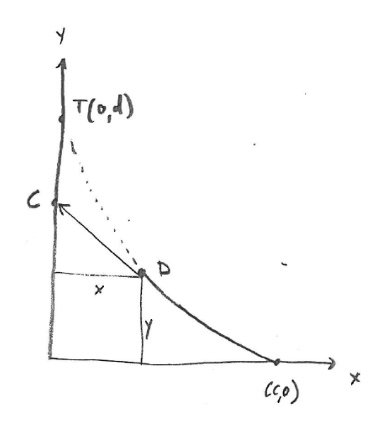

It is possible to derive an equation that describes the chase path taken by the dog in pursuing the cat.  Let $𝐷 = (𝑥, 𝑦)$ be the dog’s position as a function of time and $𝐶 = (0, 𝑎𝑡)$ be the cat’s position.  Since the dog directly chases the cat:

$$\frac{dy}{dx} = -\frac{at-y}{x}$$

$$xy'=-at+y$$

Differentiating both sides with respect to $x$:

$$xy''+y'=-a\frac{dt}{dx}+y'$$

$$xy''=-a\frac{dt}{dx}$$

If $s$ is the path of the dog and $𝑑𝑠/𝑑𝑡$ is the speed of the dog, then $𝑑𝑡/𝑑𝑥$ is related to the speed of the dog and position of the dog as follows:

$$\frac{dt}{dx}=\frac{dt}{ds}\frac{ds}{dx}=\frac{1}{b}\frac{ds}{dx}$$

$$ds=(dx^2+dy^2)^{1/2}=-dx(1+(\frac{dy}{dx})^{2})^{1/2}=-dx(1+(y')^2)^{1/2}$$

Note that the negative sign arises because $𝑠$ increases as $𝑥$ decreases.  Substituting this information,

$$\frac{dt}{dx}=-\frac{1}{b}(1+(y')^2)^{1/2}$$

$$xy''=\frac{a}{b}(1+(y')^2)^{1/2}$$

(a) What are the initial condition(s) that fully define the system?


this is an initial value ODE. this means that we have iniditial conditions for position and velocity of the dog. 
we know the initial position of the dog at x=c is y=0. 
we know the initial velocity of the dog at x=0 is also 0. 
those are the initial conditions. 


(b) Integrate this differential equation to prepare a plot of the dog’s position $y$ as a function of its $x$ position.  Assume that the cat’s speed is $𝑎 = 20$ 𝑓𝑡/𝑠, the dog’s speed is $𝑏 = 30$ 𝑓𝑡/𝑠, and $𝑐 = 150$ 𝑓𝑡.  Feel free to use any of the tools at your disposal to integrate.


The final value is 179.57151482235375


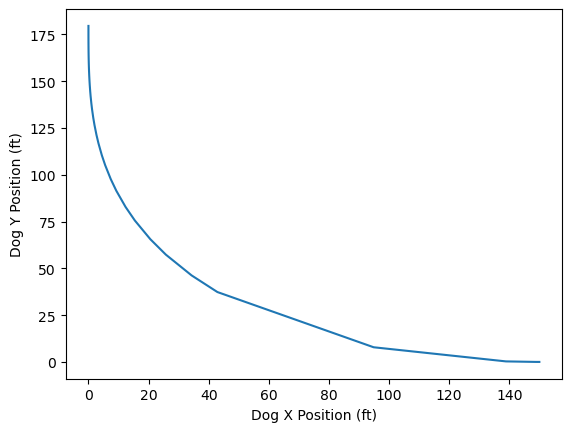

In [5]:
from scipy.integrate import solve_ivp

def stiff_chase(x,y,a=20,b=30):
    return [y[1], (a/b)*(1/x)*np.sqrt(1+y[1]**2)]

sol = solve_ivp(stiff_chase,[150,1e-6],[0,0])
plt.plot(sol.t,sol.y[0])
plt.xlabel("Dog X Position (ft)")
plt.ylabel("Dog Y Position (ft)")
print(f"The final value is {(sol.y[0][-1])}")

(c) What is the maximum distance that the cat can start from the tree to ensure that it can reach safety?

In [6]:
print(f"The max distance that the cat can start from the tree is {(sol.y[0][-1]):.4g} feet!")

The max distance that the cat can start from the tree is 179.6 feet!


(d) Plot the cat’s maximum safe distance from the tree (on the $y$-axis) as a function of the dog’s speed (on the $x$-axis).  Assume again that the cat’s speed is $𝑎 = 20$ 𝑓𝑡/𝑠 and $𝑐 = 150$ 𝑓𝑡.

/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_28229/3066293296.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  return [y[1], (a/b)*(1/x)*np.sqrt(1+y[1]**2)]
/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_28229/3066293296.py:4: RuntimeWarning: overflow encountered in scalar multiply
  return [y[1], (a/b)*(1/x)*np.sqrt(1+y[1]**2)]


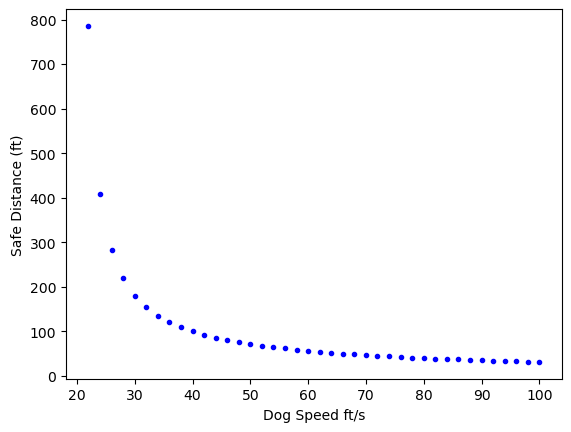

In [7]:
dog_v = np.linspace(22,100,40)
safe_dist=[]
init_x = 150
init_y = 0
init_v=0

for v in dog_v:
    sol = solve_ivp(lambda t,y: stiff_chase(t,y,20,v),[150,0],[0,0])
    safe_dist.append(sol.y[0][-1])

plt.plot(dog_v,safe_dist,'b.')
plt.ylabel("Safe Distance (ft)")
plt.xlabel("Dog Speed ft/s")
plt.show()

We can see here that the faster the dog is, the safety range for the cat is immensely smaller, similar to an inverse 1/x function.

(e) Clearly the dog could be more successful in catching the cat if it always ran toward a position $10$ 𝑓𝑡 in front of the cat rather than directly at it.  Where will the dog catch the cat under these conditions?

The max distance that the cat can start from the tree is 198.4 feet!


/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_28229/3066293296.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  return [y[1], (a/b)*(1/x)*np.sqrt(1+y[1]**2)]
/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_28229/3066293296.py:4: RuntimeWarning: overflow encountered in scalar multiply
  return [y[1], (a/b)*(1/x)*np.sqrt(1+y[1]**2)]


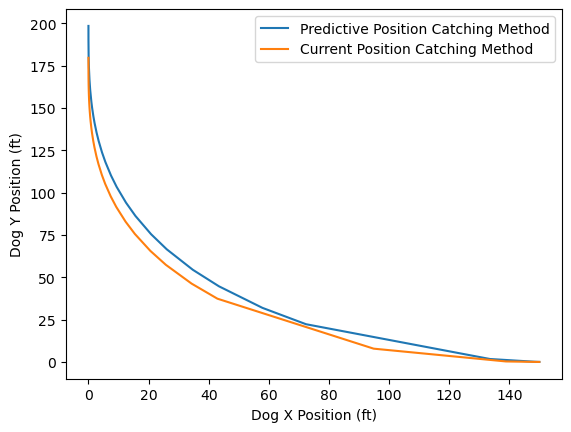

In [8]:
#ran at current position of cat

sol1 = solve_ivp(stiff_chase,[150,1e-6],[0,0])


#ran at position of cat 10 feet forwards
sol = solve_ivp(stiff_chase,[150,0],[0,-10/150])
plt.plot(sol.t,sol.y[0],label = "Predictive Position Catching Method")
plt.plot(sol1.t,sol1.y[0], label = "Current Position Catching Method")
plt.legend()

print(f"The max distance that the cat can start from the tree is {(sol.y[0][-1]):.4g} \
feet!")
plt.xlabel("Dog X Position (ft)")
plt.ylabel("Dog Y Position (ft)")
plt.show()


(f) The dog could do even better if it anticipated that the cat was headed to the tree and therefore chose to run straight towards the tree rather than the cat.  This type of pursuit path is the approach taken frequently by humans and relies upon our intelligence and predictive/integrative prowess.  Doing some research in the literature and thinking about natural systems, do predator/prey systems in nature exhibit pursuit paths described by these limiting behaviors?

The following paper might provide some inspiration: M. K. McBeath, D. M. Shaffer, M. K. Kaiser, How baseball outfielders determine where to run to catch fly balls. Science, 268, 1995, pp 569-573 (https://www.science.org/doi/10.1126/science.7725104).


Highly engineered systems often adopt the strategy defined here, in which the "predator" chases an optimal path towards a future position of the "prey". In one such example, rockets are fired on a trajectory designed to intercept a future location of the Space Station rather than the immediate location of the station. Think about all the physics, mathematics, and engineering necessary to ensure that the shuttle successfully reaches the Space Station with supplies!

Natural systems adopt a range of predation strategies. The following review (T. Y. Moore, A. A. Biewener, "Outrun or Outmaneuver: Predator-Prey Interactions as a ModelSystem for Integrating Biomechanical Studies in a Broader Ecologicaland Evolutionary Context." Integrative and Comparative Biology, 55(6), 1188-1197 (2015) http://dx.doi.org/10.1093/icb/icv074) provides insightful details on three types of predation (ambush, ballistic, and pursuit). Spiders use ambush behavior in which no prediction of the prey movement is considered. Dragonflies use ballistic behavior such that a chase trajectory is calculated based on the prey's initial movements. In ballistic predation, however, the predator does not recalculate based on any sensory feedback. The big brown bat uses pursuit behavior, in which they calculate the trajectory based on prey movement and recalculate based on sensory feedback (e.g., an updated location of the prey, including any changes in prey direction or speed).

The dog chasing cat behavior modeled in our problem is an example of pursuit behavior because the dog adjusts its trajectory, based on new information about the cat's position, when it becomes clear that the current trajectory is no longer optimal. In addition, when defining the optimal trajectory, the dog views the target as maintaining a linear trajectory with a constant speed. Considering this in the context of the numerical integration performed above, we may thus consider that the dog updates its pursuit trajectory with a frequency defined by the integration time step.

A modern-day human predator/prey system that follows a pursuit behavior is provided by a good Cubs outfielder who runs towards where they predict the ball will land rather than where the ball is in the air. I recommend reading the following Science article (M. K. McBeath, D. M. Shaffer, M. K. Kaiser, "How baseball outfielders determine where to run to catch fly balls." Science, 268(5210), 569-573 (1995) http://dx.doi.org/10.1126/science.7725104) for more information on this system. Often it is the "predictive" ability of an outfielder that determines whether they are good at their job, more so than their speed or arm strength!

There are three different types of pursuit. Spider, ballistic, and dynamic. Spider is the first dog chasing method. It sees the cat and runs straight towards it. A spider sees a target and jumps at its current position. The ballistic method is the dog's second method, it tries to predict where the cat is going, and runs (10 ft) in front of it to try and intercept it, as a ballistic missile would try and hit a target plane, for example. For the last method, the dog is too dumb to do this. This method is dynamic, the pursuer changes their chasing in real time based on how the prey is moving/changing directions/going. In this case, this might be the dog realiziing that the cat is making small adjustments in their fleeing path, where all changes head towards the tree. Instead of chasing the cat, the dog would dynamically change their trajectory and chase towards the tree, allowing for optimal chasing.  

### Problem 2 -  Stability and Implicit Euler Method

The following 2nd-order differential equation is considered to be stiff:

$$\frac{d^2x}{dt^2} + 5002\frac{dx}{dt} + 10000x = 0$$

The initial conditions are taken to be $x(0) = 3$ and $x'(0) = 4992$.

(a) Solve the differential equation to find $x(t)$ analytically. Plot the analytical solution from $t=0$ to $t=2$.

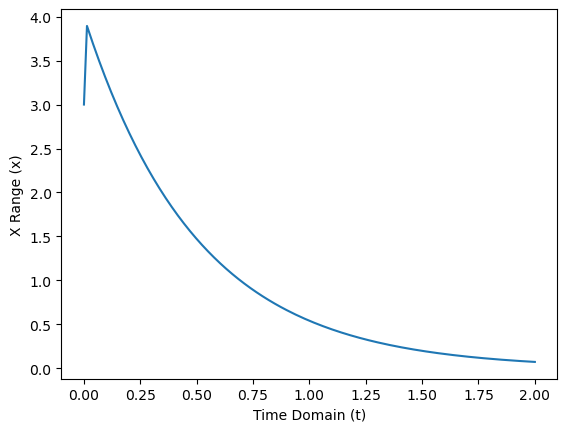

In [9]:
def x_p(t):
    return 4*np.exp(-2*t) - np.exp(-5000*t)

time_range = np.linspace(0,2,150)
plt.plot(time_range,x_p(time_range))
plt.xlabel("Time Domain (t)")
plt.ylabel("X Range (x)")
plt.show()

(b) Solve the differential equation numerically from $t=0$ to $t=2$ using the implicit Euler method with $h=0.01$.

My derivation!

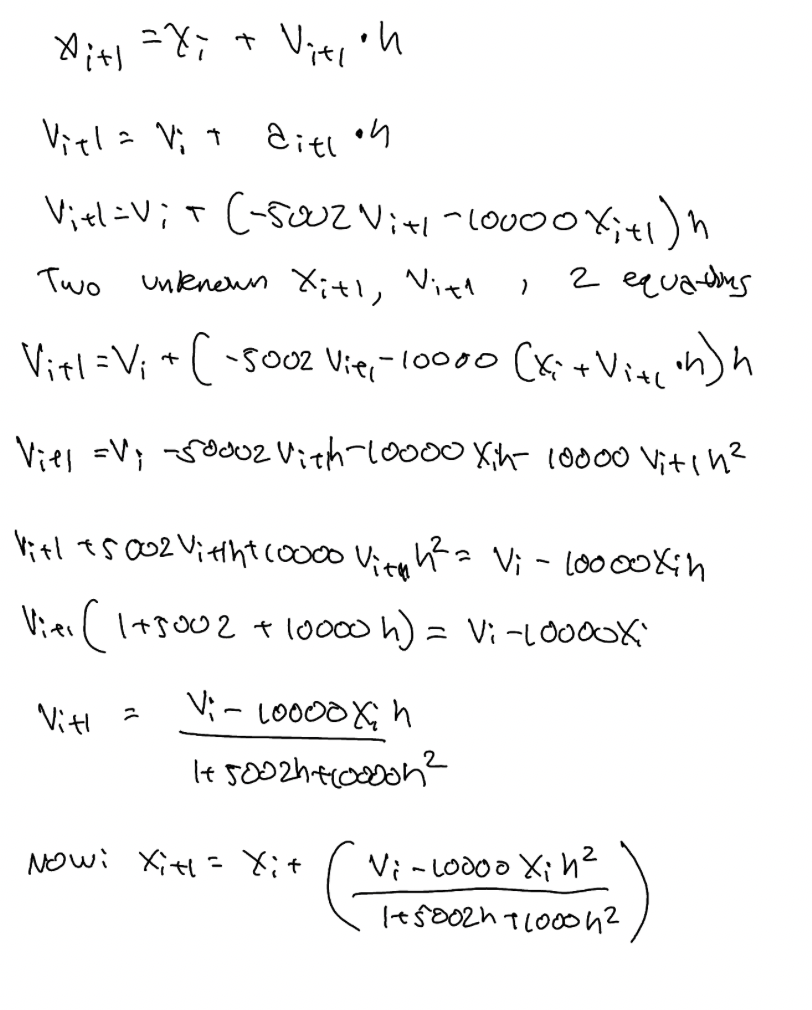

In [10]:
def implicit_euler(t,step):
    t_start = t[0]
    t_end = t[1]
    t_current = t_start

 
    old_pos = 3
    old_vel = 4992
    x_vals = [3]

    while t_current <= t_end:

        current_vel = (old_vel - 10000*old_pos*(step)) / \
(1+5002*step+(10000*(step**2)))

        current_pos = (old_pos * (1 + 5002*step) + step*old_vel) / \
((1+5002*step+(10000*(step**2))))

        

        old_pos = current_pos
        old_vel = current_vel
        x_vals.append(current_pos)

        t_current+=step
    return x_vals

imp_euler = implicit_euler([0,2],0.01)
print(len(imp_euler))


201


(c) Graph both the analytical and numerical solutions on the same plot from $t=0$ to $t=2$.

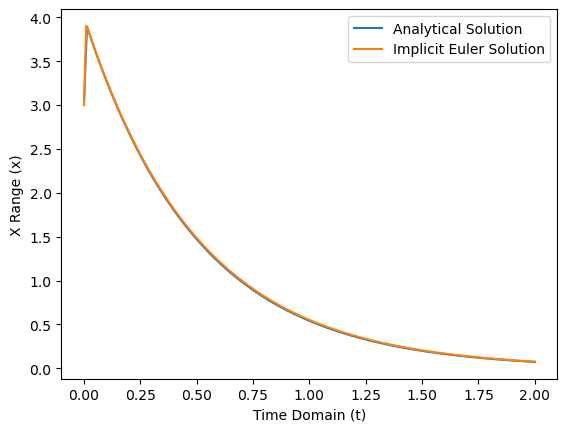

In [11]:

time_range_imp_euler = np.linspace(0,2,len(imp_euler))
time_range = np.linspace(0,2,150)
plt.plot(time_range,x_p(time_range),label = "Analytical Solution")
plt.plot(time_range_imp_euler,imp_euler, label = "Implicit Euler Solution")
plt.xlabel("Time Domain (t)")
plt.ylabel("X Range (x)")
plt.legend()

plt.show()

(d) Solve the differential equation numerically from $t=0$ to $t=2$ using the explicit Euler method.  Is there a critical step size for a convergent solution and, if so, what is the value of the critical step size?

In [12]:
def differential_2nd(position,velocity):
    return -5002*velocity - 10000*position

#this is a second order ODE. this means we need to split it into two separate 
# differential equatoins and solve

def explicit_euler(t,step,f):
    t_start = t[0]
    t_end = t[1]
    t_current = t_start

    current_pos = 3
    current_vel = 4992

    old_pos = 3
    old_vel = 4992
    x_vals = [3]

    while t_current <= t_end: 
        
        current_acc= f(old_pos,old_vel)

        current_vel = old_vel + (current_acc * step)
        current_pos = old_pos + old_vel*step

        
        old_pos = current_pos
        old_vel = current_vel
        x_vals.append(current_pos)      
        t_current+=step

    return x_vals



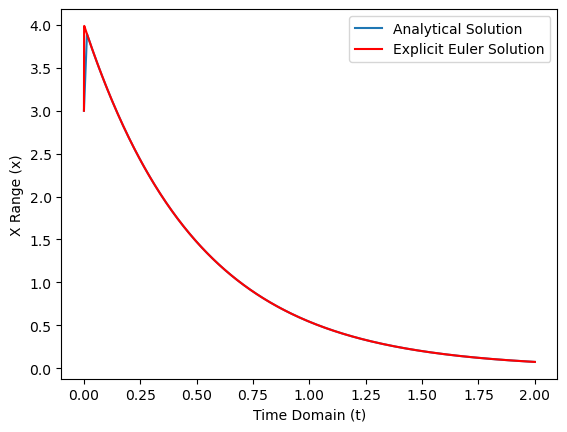

In [13]:
critical_step = (2/5000)
euler = explicit_euler([0,2],critical_step*0.01,differential_2nd)

time_range_euler = np.linspace(0,2,len(euler),endpoint=True)
time_range = np.linspace(0,2,150)

plt.plot(time_range,x_p(time_range),label = "Analytical Solution")
plt.plot(time_range_euler,euler,color="red",label="Explicit Euler Solution")
plt.xlabel("Time Domain (t)")
plt.ylabel("X Range (x)")
plt.legend()
plt.show()

(e) Generate a plot of the true percent relative error for $x(2)$ versus the step size $h$ for both the explicit and implicit Euler methods. Comment on your observations.

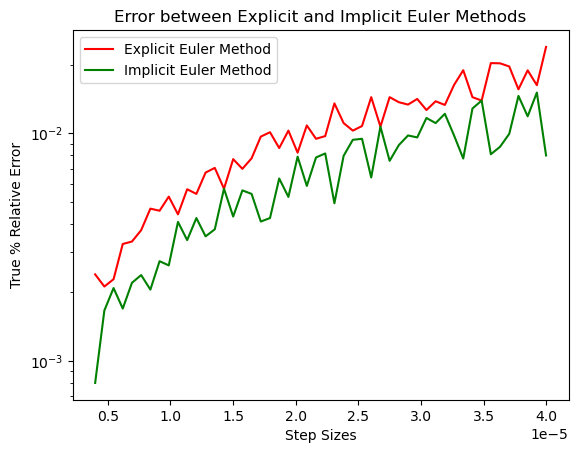

In [14]:
def true_percent_relative_err(true, list_appx):

    TR = []          
    for i in range(len(list_appx)):
        rel_err = (np.abs(true - list_appx[i]) / true) * 100
        TR.append(rel_err)
    return(TR)

def x(t):
    return 4*np.exp(-2*t) - np.exp(-5000*t)

true_val = x(2)
critical_step = (2/5002)

#step_sizes_implicit = np.linspace(critical_step,0.01,150)
#step_sizes_implicit = np.linspace(critical_step*0.1,0.01,150)
step_sizes_euler = np.linspace(critical_step*0.01,critical_step*0.1,50)




implicit_appxs = []
explicit_appxs = []

for step in step_sizes_euler:
    implicit_guess = implicit_euler([0,2], step)[-1]
    implicit_appxs.append(implicit_guess)
    explicit_guess = explicit_euler([0,2],step,differential_2nd)[-1]
    explicit_appxs.append(explicit_guess)   


explicit_err = true_percent_relative_err(true_val, explicit_appxs)

implicit_err = true_percent_relative_err(true_val, implicit_appxs)


plt.semilogy(step_sizes_euler,explicit_err,color="red",label = "Explicit Euler Method")
plt.semilogy(step_sizes_euler,implicit_err, c = "green",label = "Implicit Euler Method")
plt.xlabel("Step Sizes")
plt.ylabel("True % Relative Error")
plt.title("Error between Explicit and Implicit Euler Methods")
plt.legend()
plt.show()

We can see here that the implicit method has slightly less error than the explicit method. There could be multiple reasons for this. 

One is because the function is a stiff function. That means that inherently, the explicit method suffers more as it relies on step size to even converge. We can see in the graph from 2d that the initial jump isn't able to be captured well by the explicit method, regardless of the stepsize that we choose to use. This will already cause some error (not relevant in this question, since we're evaluating error at the final point). Basically, explicit functions have to treat stiff functions differently, whereas implicit functions don't, which should help decrease error. 

The implicit is also better because it's predictive. It can predict the large jump (stiff) in the initial curve, and predict that it's going to decline later, allowing for less error. Additionally (this was briefly mentioned before), but accuracy of explicit method is highly conditional on step size. Here, the stepsizes aren't that small, and "closer" to the critical explict euler method step size. Perhaps if the step size was signifigantly smaller, than the errors would look more similar. 

(f) Generate a plot of the runtime versus step size for both the explicit and implicit Euler methods.  Comment on your observations.

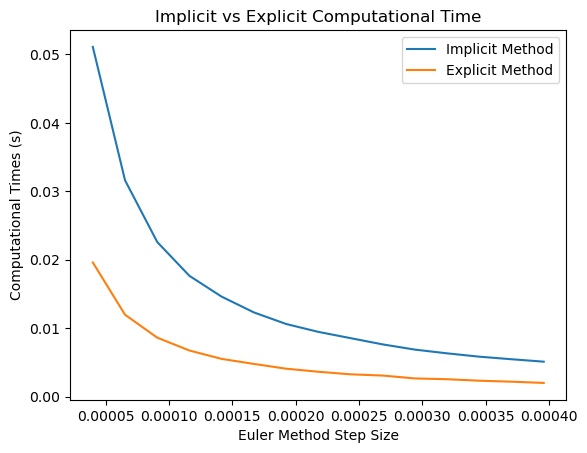

In [15]:
import time

# step_sizes_implicit = np.linspace(critical_step*0.01,0.01,150)
# step_sizes_explicit = np.linspace(critical_step*0.01,critical_step,150)
step_sizes_implicit = np.linspace(critical_step*0.1,critical_step*0.99,15)
step_sizes_explicit = np.linspace(critical_step*0.1,critical_step*0.99,15)

implicit_times = []
explicit_times =[]

for step in step_sizes_implicit:
    t0=time.time()
    
    for i in range(2):
        implicit_euler([0,2], step)
    t1=time.time()
    implicit_times.append((t1-t0) / 2)
    #print(step)


for step in step_sizes_explicit:
    t0=time.time()
    
    for i in range(2):
        explicit_euler([0,2], step,differential_2nd)
    t1=time.time()
    explicit_times.append((t1-t0) / 2)

plt.plot(step_sizes_implicit,implicit_times,label = "Implicit Method")
plt.plot(step_sizes_explicit,explicit_times,label = "Explicit Method")
plt.xlabel("Euler Method Step Size")
plt.ylabel("Computational Times (s)")
plt.title("Implicit vs Explicit Computational Time")
plt.legend()
plt.show()

I observed that the explicit method is much more computational favorable than the implicit method. 

This is because the implicit method has to do more raw calculations than the explicit method. For the explicit method, we just put in our current positions/velocities and it calculates the predicted ones. For implicit, it has to predict the values and then use those predicted values to calculate the final prediction. 

In terms of the code, our raw explicit math is simple: we call our acceleration function and then use that value to calculate our current velocity and position while using one addition and one multiplication step. 

For the implicit code, we can see that there's a lot more complexity. We have to do lots of nested divisions, additions, and multiplications while squaring a step size. This squaring is probably why (at smaller step sizes), our implicit method takes much more computation time. 

Note that the actual time differences varies by ~0.03 seconds, which is very little. This difference might be able to be decreases by writing more efficient code for the implicit method. 

### Problem 3 - Heat Conduction in a Hollow Cylinder

*Adapted from Kiusalaas, Numerical Methods in Engineering with Python, Problem Set 8.2.*

A hollow cylinder has outer radius of $2$ and inner radius of $1$.  For $r\in[1,2]$, the steady-state heat temperature $T(r)$ in the cylinder satisfies the ODE
$$\frac{d^2T}{dr^2}=-\frac{1}{r}\frac{dT}{dr}$$
where $T(1)=0$ (*i.e.*, the inner cavity is maintained at $0^\circ\mathrm{C}$).

(a) Let $\phi(r)=\frac{dT}{dr}$. Rewrite the ODE as a first-order system of the form
$$ \begin{pmatrix}T\\ \phi\end{pmatrix}' = F(r,\phi,T). $$

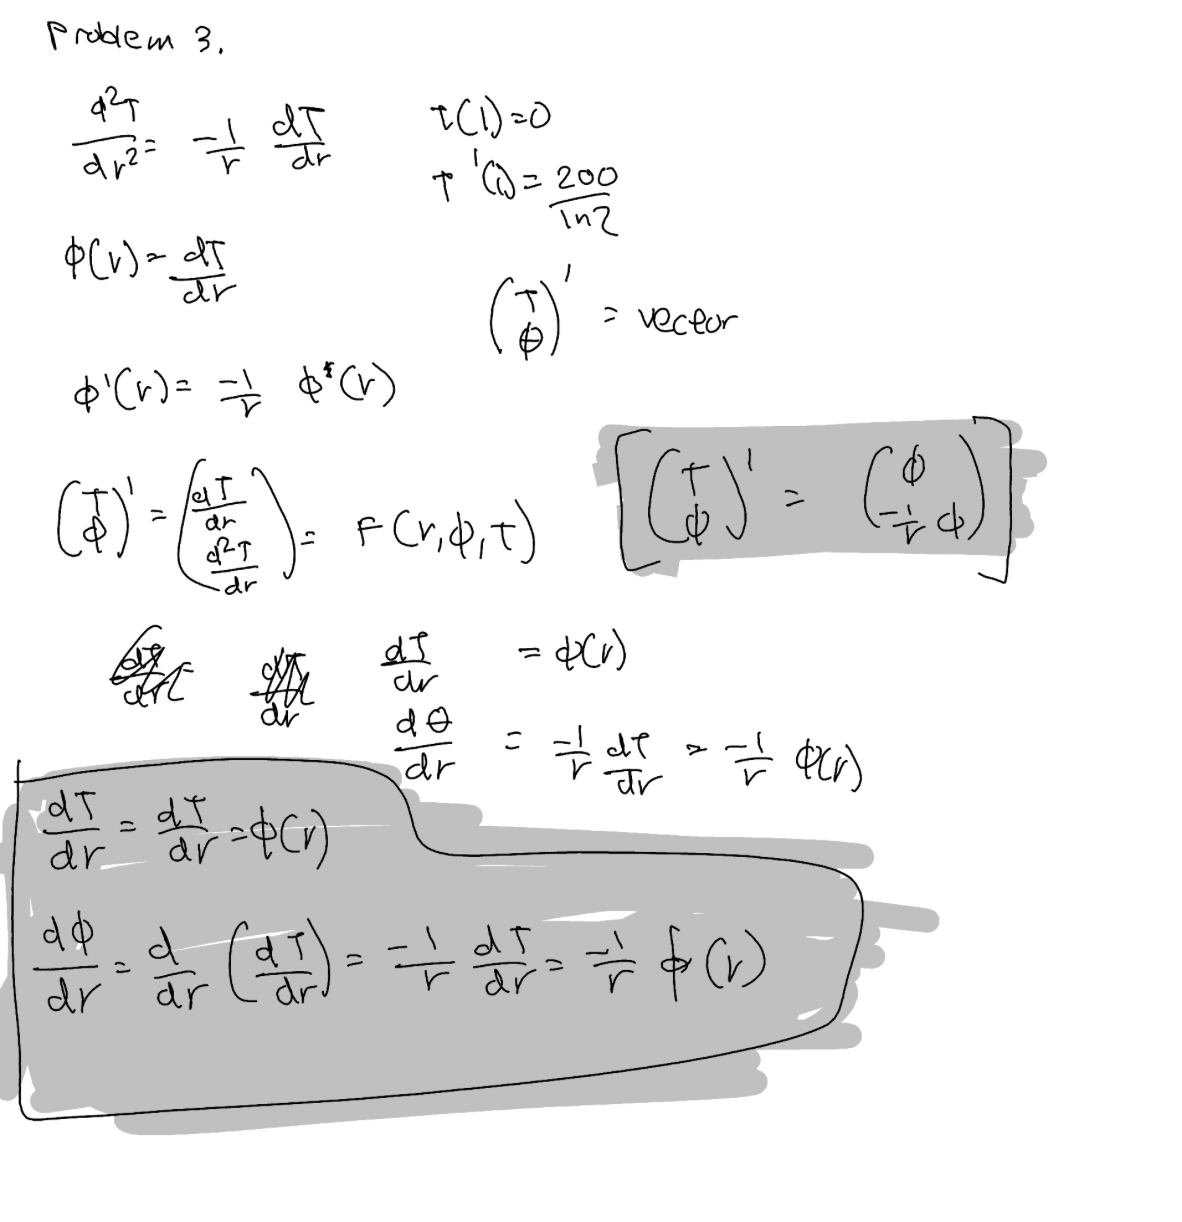

(b) Suppose for now that
$$\phi(1)=\frac{200}{\ln 2}$$

$\quad$ (i) Using the relation from (a), implement **Heun’s method** and the **explicit midpoint method** to approximate $T(r)$ on $r\in[1,2]$ with step size $\Delta r=0.05$.

In [16]:
def ddT(r,dT):
    #r is the indepdent variable
    #dT is the dependent variable
    return - (1/r) * dT

def explicit_midpoint(f,r,step,method):
   
    if method =="heun":
        a1 = 0.5
        a2 = 0.5
        p1 = 1
        q11 = 1
    elif method =="midpoint":
        a1 = 0
        a2 = 1
        p1 = 1/2
        q11 = 1/2

    t_start, t_end = r[0],r[1]
    t_current = t_start

    current_temp = 0
    current_tempslope = (200 / np.log(2))

    old_temp = 0 
    old_tempslope = (200 / np.log(2))
   
    t_vals = [0]
    
    #while t_current <= t_end:
    r_range = np.arange(t_start,t_end,step)
    for r_current in r_range:
        
        #r is equilvanet to x, tempslope equivalent to Y

        #k1 is the current (derivative)
        #k2 is the predicted (derivative), which we're calculating by looking at the
        #  next "point," which is, in this case, the midpoint. 

        k1_PHI = f(r_current,old_tempslope)
        k1 = old_tempslope

        #k2 = predicted slope
        k2 = old_tempslope + (q11*step*k1_PHI)
        k2_PHI = f(r_current+p1*step,old_tempslope+q11*step*k1_PHI)
        
        
        current_tempslope = old_tempslope+(a1*k1_PHI + a2*k2_PHI)*step
        current_temp = old_temp +(a1*k1+a2*k2)*step

        old_tempslope = current_tempslope
        old_temp = current_temp
        t_vals.append(current_temp)

    return t_vals


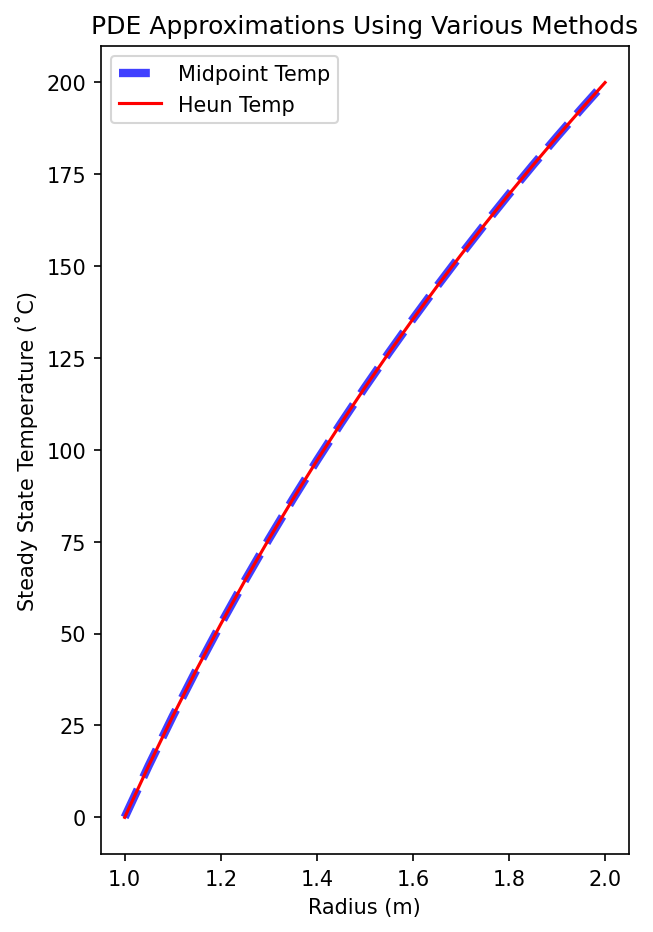

199.96421559191631
199.90718902904652


In [17]:

midpoint = explicit_midpoint(ddT,[1,2],0.05,"midpoint")
heun = explicit_midpoint(ddT,[1,2],0.05,"heun")

r_range = np.linspace(1,2,len(midpoint))

plt.figure(figsize=(10,7),dpi=150)

plt.subplot(121)

plt.plot(r_range,midpoint,c="blue", label = "Midpoint Temp",linewidth=4,alpha=0.75,\
linestyle="--")
plt.plot(r_range,heun,c="red",label = "Heun Temp")
plt.title("PDE Approximations Using Various Methods")
plt.ylabel("Steady State Temperature (˚C)")
plt.xlabel("Radius (m)")
plt.legend()
plt.show()


print(midpoint[-1])
print(heun[-1])

$\quad$(ii) You are now given the analytical solution for $r\in[1,2]$:
$$
T_A(r)=200\,\frac{\ln r}{\ln 2}.
$$
Plot $T_A(r)$, $T_{\text{Heun}}(r)$, and $T_{\text{Mid}}(r)$ on the same figure. Make sure that the three curves can be easily distinguished.

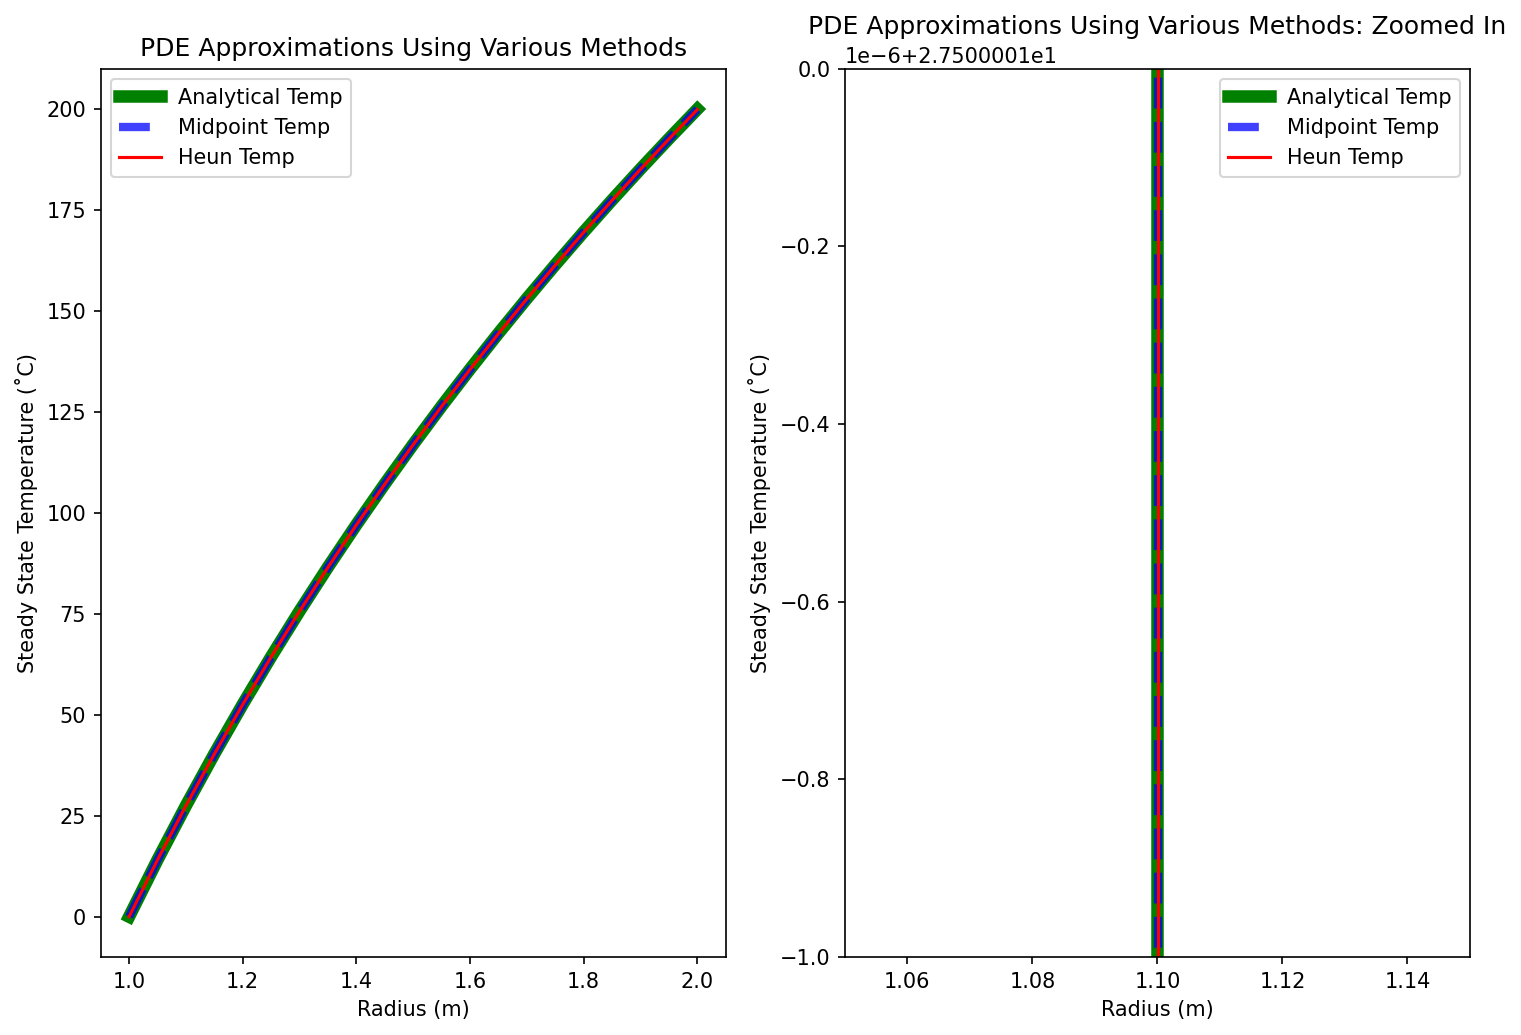

In [18]:
def analytical_temp(r):
    return 200*(np.log(r) / np.log(2))

midpoint = explicit_midpoint(ddT,[1,2],0.05,"midpoint")
heun = explicit_midpoint(ddT,[1,2],0.05,"heun")

r_range = np.linspace(1,2,len(midpoint))

plt.figure(figsize=(10,7),dpi=150)

plt.subplot(121)
plt.plot(r_range,analytical_temp(r_range),c="green",label = "Analytical Temp",linewidth=6)
plt.plot(r_range,midpoint,c="blue", label = "Midpoint Temp",linewidth=4,alpha=0.75,\
linestyle="--")
plt.plot(r_range,heun,c="red",label = "Heun Temp")
plt.title("PDE Approximations Using Various Methods")
plt.ylabel("Steady State Temperature (˚C)")
plt.xlabel("Radius (m)")
plt.legend()

plt.subplot(122)
plt.plot(r_range,analytical_temp(r_range),c="green",label = "Analytical Temp",linewidth=6)
plt.plot(r_range,midpoint,c="blue", label = "Midpoint Temp",linewidth=4,alpha=0.75,\
linestyle="--")
plt.plot(r_range,heun,c="red",label = "Heun Temp")
plt.xlim(1.05,1.15)
plt.ylim(27.5,27.500001)
plt.title("PDE Approximations Using Various Methods: Zoomed In")
plt.legend()
plt.ylabel("Steady State Temperature (˚C)")
plt.xlabel("Radius (m)")
plt.tight_layout()



(c) Define the true error at the endpoint of the integration (*i.e.*, when $r=2$) for a given step size as
$$
E(\Delta r)=\left|T_{approx with \Delta r}(2)-T_A(2)\right|.
$$

$\quad$ (i) Compute and print $E(\Delta r)$ for $\Delta r\in\{0.1,\,0.05,\,0.025,\,0.0125\}$ for both Heun’s method and the explicit midpoint method.

In [19]:
def true_err(true,appx):
    err = []
    for i in range(len(appx)):
        error = np.abs(appx[i] - true)
        err.append(error)
        #print(err)

    return err

midpoint_appxs = []
heun_appxs =[]

step_sizes = [0.1,0.05,0.025,0.0125]
true_temp = analytical_temp(2)

for step in step_sizes:
    midpoint_appxs.append(explicit_midpoint(ddT,[1,2],step,"midpoint")[-1])
    heun_appxs.append(explicit_midpoint(ddT,[1,2],step,"heun")[-1])

midpoint_err = true_err(true_temp,midpoint_appxs)
heun_err = true_err(true_temp,heun_appxs)

print(f"The true error of the Heun method at r=2 for each step size is as follows: ∆r = \
0.1: err = {heun_err[0]:.4g}, ∆r = 0.05: err = {heun_err[1]:4g}, \
∆r = 0.025: err = {heun_err[2]:.4g},\
∆r = 0.0125: err = {heun_err[3]:.4g}.")
print(f"The true error of the Midpoint method at r=2 for each step size is as follows: \
∆r = 0.1: err = {midpoint_err[0]:.4g}, ∆r = 0.05: err = {midpoint_err[1]:4g}, \
∆r = 0.025: \
err = {midpoint_err[2]:.4g}, ∆r = 0.0125: err = {midpoint_err[3]:.4g}.")

The true error of the Heun method at r=2 for each step size is as follows: ∆r = 0.1: err = 0.3819, ∆r = 0.05: err = 0.092811, ∆r = 0.025: err = 0.02287,∆r = 0.0125: err = 0.005677.
The true error of the Midpoint method at r=2 for each step size is as follows: ∆r = 0.1: err = 0.1563, ∆r = 0.05: err = 0.0357844, ∆r = 0.025: err = 0.008563, ∆r = 0.0125: err = 0.002095.


$\quad$ (ii) Make a log-log plot of $E(\Delta r)$ versus $\Delta r$ for both methods on the same figure.

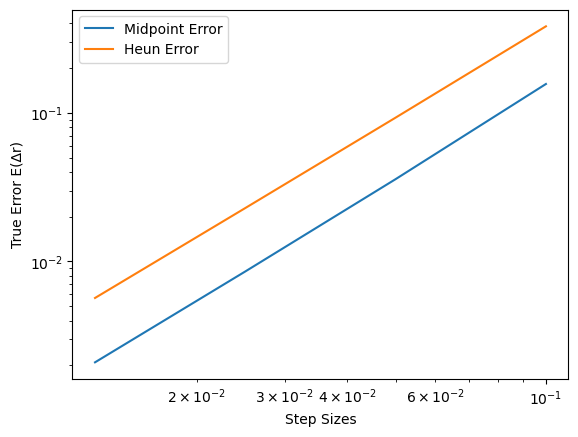

In [20]:
plt.loglog(step_sizes,midpoint_err,label = "Midpoint Error")
plt.loglog(step_sizes,heun_err, label = "Heun Error")
plt.xlabel("Step Sizes")
plt.ylabel("True Error E(∆r)")
plt.legend();


$\quad$ (iii) Estimate the slope for each method from the log-log plot by least squares regression. Does it match the expected global truncation error order for each method?

In [21]:
from scipy.stats import linregress

midpoint_regression = linregress(np.log10(step_sizes), np.log10(midpoint_err))
heun_regression = linregress(np.log10(step_sizes),np.log10(heun_err))


print(f"Midpoint Error Regression Slope: {midpoint_regression[0]}")
print(f"Heun Error Regression Slope: {heun_regression[0]}")


Midpoint Error Regression Slope: 2.0726936571112806
Heun Error Regression Slope: 2.0236648132795447


We can see that the two slope of errors match the expected global truncation error order of each method. This is expected, as these methods are derived using the 2nd order runge-kutta method, which means that the global truncation error is 2nd order (because of taylor expansion). Therefore, we'd expect to see 2nd order global truncation error for both heun and midpoint methods, and this is what we observe in the slopes of their errors

(d) You have now measured the temperature of the outer surface of the cylinder to be $200^\circ\mathrm{C}$.  In addition, $T(1)=0$. However, now the initial condition defined in part (b) no longer holds.

Take a uniform grid on $r\in[1,2]$ with $\Delta r=0.05$. Use **centered finite differences** at interior points to form a tridiagonal linear system for the unknown temperatures using the boundary conditions.

$\quad$ (i) Solve the system to obtain $T_{\text{FD}}(r)$ on the grid.

In [ ]:
def CFD(step,r_range,BC1,BC2):
    r_start, r_end = r_range[0],r_range[1]
    #intervals = (r_end - r_start ) / step

    number = np.arange(r_start,r_end+step/2,step)
    #print(number)
    length = len(number)
    array_length = length - 2

    A = np.zeros((array_length,array_length))

    c = np.zeros((array_length,1))

    for i in range(array_length):
        r = number[i+1]

        A_coeff = ((1/step**2) + (1/(2*step*r)))
        #A_coeff corresponds to the y_i+1, so needs to correspond to the A[i,i+1]
        B_coeff = (-2 /step**2)
        C_coeff = ((1/step**2) - (1/(2*step*r)))


#these if conditions are for the boundary contions. we need to make sure that our 
# knowns/C vector is our boundary condition
        if i==0:
            c[i] = -C_coeff*BC1
        else: 
            A[i,i-1] = C_coeff

        if i==array_length-1:
            c[i]=-A_coeff*BC2
        else: 
            A[i,i+1]= A_coeff
#this is a diagnol matrix!
        A[i,i] = B_coeff

    return A,c,number

A,c,number = CFD(0.05, [1,2],0,200) 
print(A)
#print(c)
b = np.linalg.solve(A,c)

#note, these are only the interior grids
# print(b)
# print(type(b))
# print(b.ndim)

# flat = b.flatten()
# # print(flat.ndim)

# full_b = np.concatenate(([0],flat,[200]))
# r_range = np.arange(1,2+0.05,0.05)
# # print(len(full_b))
# # print(len(r_range))
# plt.plot(r_range,full_b)

def combiner(step):
    coefficient, RHS,number = CFD(step,[1,2],0,200)
    temps = np.linalg.solve(coefficient,RHS)
    temps=temps.flatten()
    full_temps = np.concatenate(([0],temps,[200]))
    return full_temps

#print(b)


[[-800.          409.52380952    0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.        ]
 [ 390.90909091 -800.          409.09090909    0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.        ]
 [   0.          391.30434783 -800.          408.69565217    0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.        ]
 [   0.            0.          391.66666667 -800.          408.33333333
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            

$\quad$ (ii) Plot $T_A(r)$ and $T_{\text{FD}}(r)$ on the same figure. Make sure that the two curves can be easily distinguished and are clearly labeled.

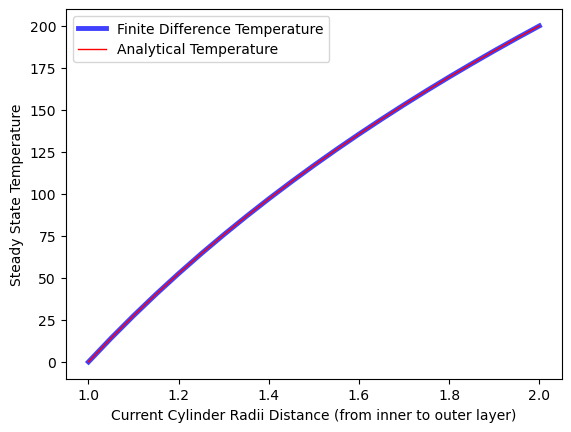

In [23]:
plt.plot(r_range,combiner(0.05), c= "blue", label = "Finite Difference Temperature",\
linewidth=3.5,alpha=0.75)
plt.plot(r_range,analytical_temp(r_range),c="red",label = "Analytical Temperature",\
linewidth=1)
plt.xlabel("Current Cylinder Radii Distance (from inner to outer layer)")
plt.ylabel("Steady State Temperature")
plt.legend()
plt.show()


(e) Define the error metric
$$
E(\Delta r)=\max_j \left|T_j-T_A(r_j)\right|
$$
where $j$ indexes the grid points in the finite difference solution.

$\quad$ (i) Compute and print $E(\Delta r)$ for $\Delta r\in\{0.1,\,0.05,\,0.025,\,0.0125\}$.

In [3]:

r_step_sizes = [0.1,0.05,0.025,0.0125]
errors = []
#r_range = np.arange(1,2+0.05,0.05)

# def combiner(step):
#     coefficient, RHS = function(step,[1,2],0,200)
#     temps = np.linalg.solve(coefficient,RHS)
#     temps=temps.flatten()
#     full_temps = np.concatenate(([0],temps,[200]))
#     return full_temps

for step in r_step_sizes:

    coefficient, RHS,number = CFD(step,[1,2],0,200)
    full_temps = np.concatenate(([0],(np.linalg.solve(coefficient,RHS)).flatten(),[200]))


    # r_iter_linspace = np.linspace(1,2,len(current_appx))

    # r_iter_range = np.arange(1,2+step,step)
    # print(len(r_iter_range))
    # print(len(current_appx))
    # print(len(r_iter_range))
    true = analytical_temp(number)
    error = np.max(np.abs(full_temps - true))
    errors.append(error)



print(f"The MAX true error of the Finite Difference method for the boundary conditions \
for each step size is as follows: ∆r = 0.01: err = {errors[0]:.4g}, ∆r = 0.05: err = \
{errors[1]:4g}, ∆r = 0.025: err = {errors[2]:.4g}, ∆r = 0.0125: err = {errors[3]:.4g}.")

NameError: name 'analytical_temp' is not defined

$\quad$ (ii) Make a log-log plot of $E(\Delta r)$ versus $\Delta r$.

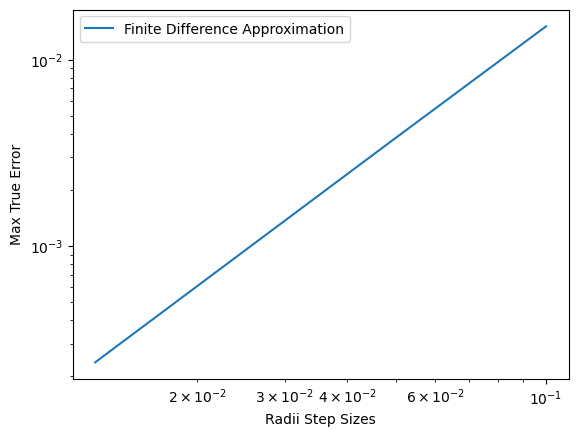

In [22]:
r_step_sizes = [0.1,0.05,0.025,0.0125]

plt.loglog(r_step_sizes,errors,label = "Finite Difference Approximation")
plt.xlabel("Radii Step Sizes")
plt.ylabel("Max True Error")
plt.legend();


$\quad$ (iii) Estimate the slope from the log-log plot by least squares regression. Does it match the expected global truncation error order?

In [23]:
from scipy.stats import linregress

FD_regression = linregress(np.log(r_step_sizes), np.log(errors))


print(f"Global Truncation Error by Least Squares Regression: {FD_regression[0]:.5f}")

Global Truncation Error by Least Squares Regression: 1.99531


Yes, our Central Finite Differences method matches the expected global truncation error. If we look at the original central finite difference derivative approximation, it has an error of the second order. Since we're incorporating the lower order central finite difference method and using it to derive this finite difference BVP solution, we'd expect our final solution to have the same error (O(h^2)). We can see that it does through the slope of error. 

 ### Problem 4 - Shooting (Method) a Satellite Into Space

Logan wants to launch a satellite as part of the UChicago Space Program. Let $y(t)$ be the altitude (in meters from the surface) of the satellite at time $t$. For an initial trial, Logan will ignore all forces on the satellite except that of gravity ($g=$ 9.8 m/s$^2$). He wants to have the satellite be 50,000 meters away from the surface of the earth after 60 seconds.  Therefore, we know:

$$\frac{d^2y}{dt^2} = -9.8$$

$$y(0) = 0$$

$$y(60) = 50,000$$

(a) Recast this differential equation as a system of two first-order differential equations.  

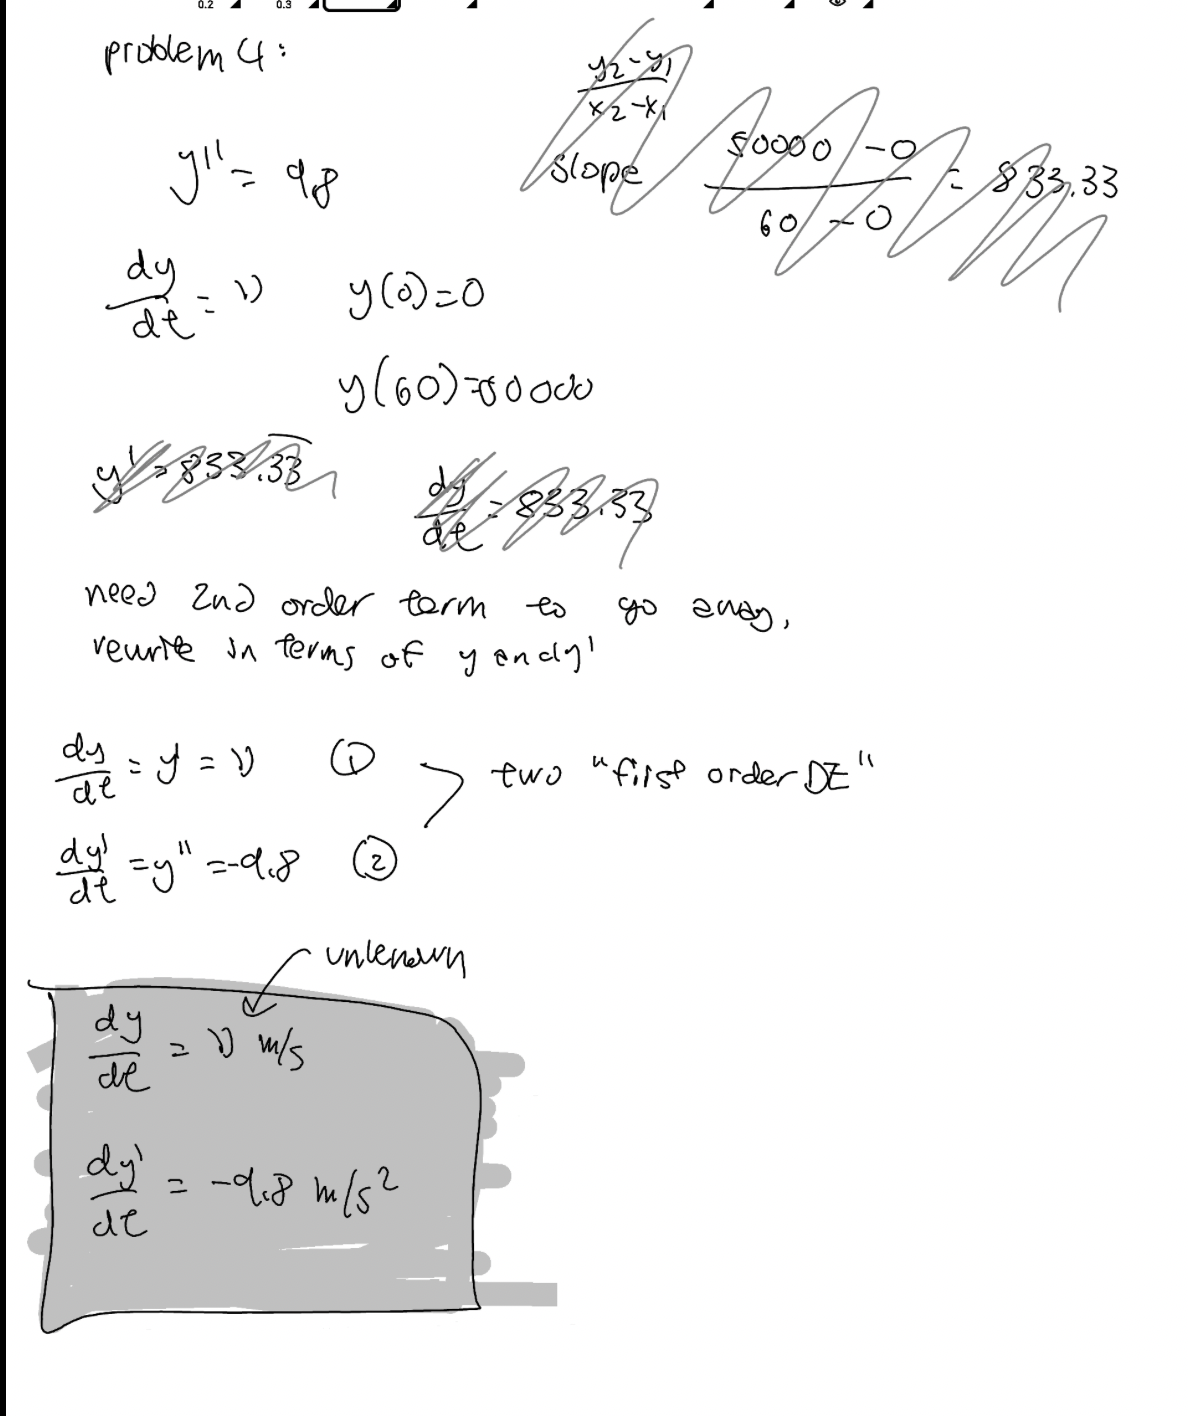

(b) Implement the shooting method to solve the equation given the boundary conditions of $y(0) = 0$ and  $y(60) = 50,000$ m.  Provide a plot of your approximations for $y(t)$ for each attempt of the shooting method until it converges on a final solution, and demonstrate the final solution satisfies the boundary conditions.  

In [ ]:
def runge_kutta_4th_shoot(initial_vel, t, step,accel=-9.8):
    old_pos = 0
    old_vel=initial_vel

    t_start, t_end = t[0],t[1]

    t_current = t_start
    
    y_vals = [old_pos]
    
    while t_current < t_end:

        k1_vel = accel
        k1 = old_vel

        k2 = old_vel+0.5*k1_vel*step
        k2_vel = accel #+0.5*k1_vel*step

        k3=old_vel + 0.5*k2_vel*step
        k3_vel = accel#+0.5*k2_vel*step

        k4 = old_vel + k3_vel*step
        k4_vel = accel#+k3_vel*step

        current_vel = old_vel + (1/6)*(k1_vel+ 2*k2_vel + 2*k3_vel+k4_vel)*step

        current_pos = old_pos + (1/6) * (k1 + 2*k2 + 2*k3 + k4) * step

        old_vel = current_vel
        old_pos = current_pos

        y_vals.append(current_pos)
        t_current += step
    return y_vals, y_vals[-1]


def shooter(BC2,initial_guess_1,initial_guess_2,ODE,t,step,tol,accel=-9.8):


    call_ODE_1 = ODE(initial_guess_1,t,step,accel)
    old_prediction = call_ODE_1[1]
    old_guess = initial_guess_1

    call_ODE_2 = ODE(initial_guess_2,t,step,accel)
    current_prediction = call_ODE_2[1]
    current_guess = initial_guess_2
    
    guesses = [initial_guess_1,initial_guess_2]
    y_vals = [call_ODE_1,call_ODE_2]
    err = current_prediction-BC2
    #guess_range = np.arange(guess_start,guess_end,step)
    #for guess in guess_range:
    while np.abs(err) >= tol:

        next_guess = current_guess - ((current_guess - old_guess) / ((current_prediction \
- BC2) - (old_prediction - BC2) )) *( current_prediction - BC2)

        old_guess = current_guess
        current_guess = next_guess
        
        old_prediction = current_prediction

        #call_ODE is the make an arbitrary variable so we don't have 
        # to call the ODE function twice
        call_ODE = ODE(current_guess,t,step,accel)
        current_prediction = call_ODE[1]

        guesses.append(next_guess)
        y_vals.append(call_ODE)
        #err = ODE(next_guess,t,step)[-1] - BC2
        err = current_prediction - BC2
    #next guess is our initial value guess, guesses is the guesses for initial value, 
    # y_vals is the ODE y values
    return next_guess,guesses,y_vals

shooter_results = shooter(50000,800.000,900.000,runge_kutta_4th_shoot, [0,60],0.1,1e-6)

print(f"Shooter Method Initial Velocity Guesses: {shooter_results[1]} m/s")

Shooter Method Initial Velocity Guesses: [800.0, 900.0, 1127.3333333333387] m/s


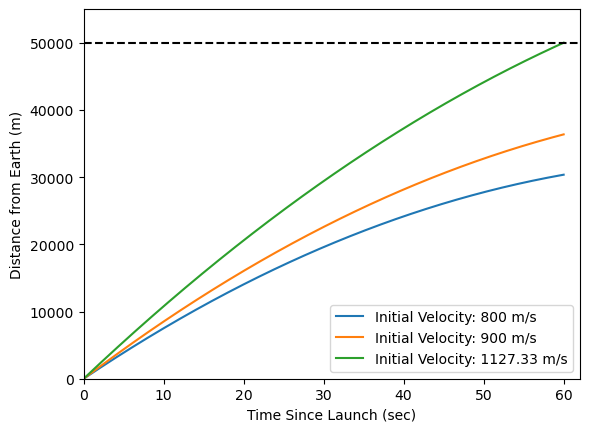

In [54]:
# Basically, 
# [2] gets the list of all the ODE y values
# [0] gets the first ODE with the first guess
# [0] indexes into the list, because the original ODE is returned as list

time_range = np.linspace(0,60,len(shooter_results[2][0][0]))
plt.plot(time_range, shooter_results[2][0][0],label = f"Initial Velocity: \
{shooter_results[1][0]:.6g} m/s")
plt.plot(time_range, shooter_results[2][1][0],label = f"Initial Velocity: \
{shooter_results[1][1]:.6g} m/s")
plt.plot(time_range, shooter_results[2][2][0],label = f"Initial Velocity: \
{shooter_results[1][2]:.6g} m/s")
plt.ylim(0,55000)
plt.xlim(0,62)
plt.xlabel("Time Since Launch (sec)")
plt.ylabel("Distance from Earth (m)")
plt.axhline(y=50000,linestyle="--", c="black")
plt.legend()
plt.show()

(c) Provide plots of the velocity and acceleration of the satellite with respect to time. 

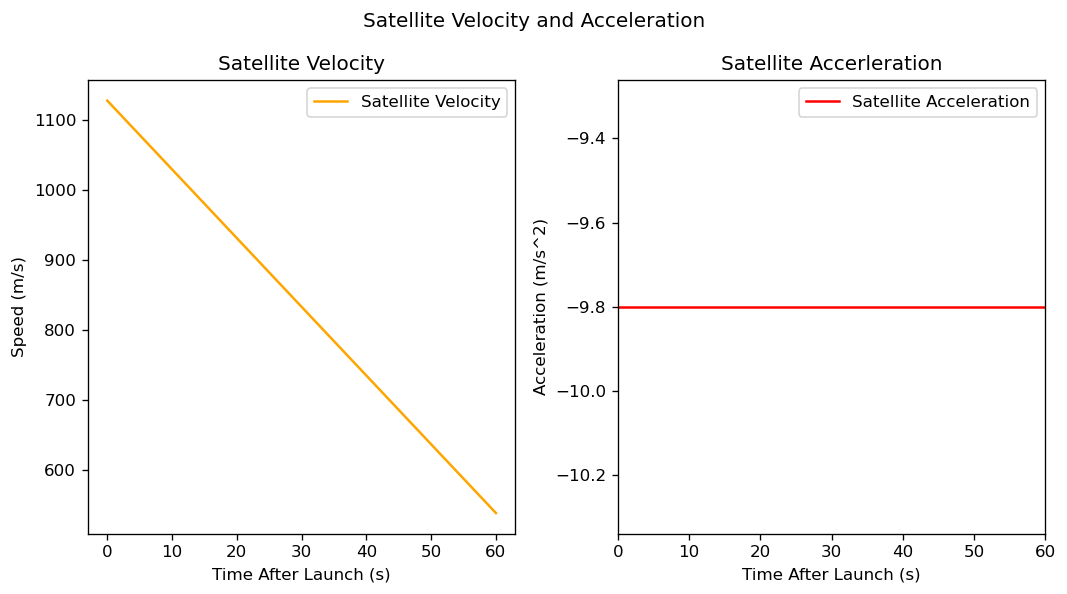

In [55]:

initial_vel =shooter_results[1][2]
time_range = np.linspace(0,60,len(shooter_results[2][0][0]))

velocity = initial_vel-9.8*time_range


plt.figure(figsize=(9, 5), dpi=120)

#row, column, position
plt.subplot(121)
plt.suptitle("Satellite Velocity and Acceleration")


plt.plot(time_range,velocity,c="orange",label = "Satellite Velocity")
plt.xlabel("Time After Launch (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.title("Satellite Velocity")

plt.subplot(122)
plt.axhline(y=-9.8,color="red", label = "Satellite Acceleration")
plt.title("Satellite Accerleration")
plt.xlabel("Time After Launch (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.xlim(0,60)
plt.legend()


plt.tight_layout()


(d) Logan did so well in MENG 21200 that NASA is recruiting him to test the process of launching satellites from different planets. Help Logan analyze how different values of gravity impacts the rate at which the satellites reach 50,000 meters in altitude.  At minimum, try $g$ values between 5 and 50 m$^2$.  Interpret your results in terms of the physical system and what you observe. Why does this make sense?  


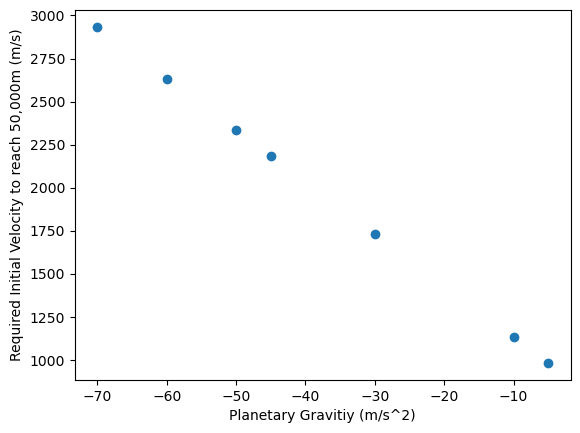

In [ ]:
#note, i'm assuming that "RATE" means initial velocity, 
# not the time it takes to reach 50,000

g_vals = [-5,-10,-30,-45,-50,-60,-70]
rates = []
for g in g_vals:
    rate = shooter(50000,800,900,runge_kutta_4th_shoot,[0,60],0.1,1e-6,g)
    rates.append(rate[1][2])
    #print(rate[1][2])

plt.scatter(g_vals,rates)
plt.xlabel("Planetary Gravitiy (m/s^2)")
plt.ylabel("Required Initial Velocity to reach 50,000m (m/s)")
plt.show()

Interpreting the results, we see that there is a linear dependence between acceleration and required initial velocity. We can see this based on our initial ODE system, where the only thing affecting velocity is a constant acceleration, and there are no other independent variables. In terms of the physical aspect, the more gravity there is, the more "negative" forces / resistance there is acting against our satellite, i.e., it's heavy and takes more energy / speed to reach 50,000m

(e) Logan returns to working on the UChicago Space Program satellite that he is launching from Earth. He decides to update his differential equation to account for the force of drag. The force due to drag is $a_{drag} = \frac{1}{2m}⍴v^2C_d A $ (acceleration due to drag). Therefore, our updated equation and boundary conditions are:

$$\frac{d^2y}{dt^2} = -9.8 - \frac{\rho A C_d}{2m} \left(\frac{dy}{dt}\right)^2$$

with $y(0) = 0$ and $y(60) = 50,000$ m,

and $C_d = 0.005$, $\rho = 1.225$ (kg/m$^3$), $A = 5$ m$^2$, $m= 100$ kg.

Solve using the shooting method and plot $y(t)$ versus $t$ using the updated equation of forces.

Shooter Method Initial Velocity Guesses: [650000.0, 750000.0, 734428.8969984846, 733461.9363113254, 733472.6780895416] m/s
Our required initial velocity by the SHOOTER METHOD is 733472.6780895416 m/s.


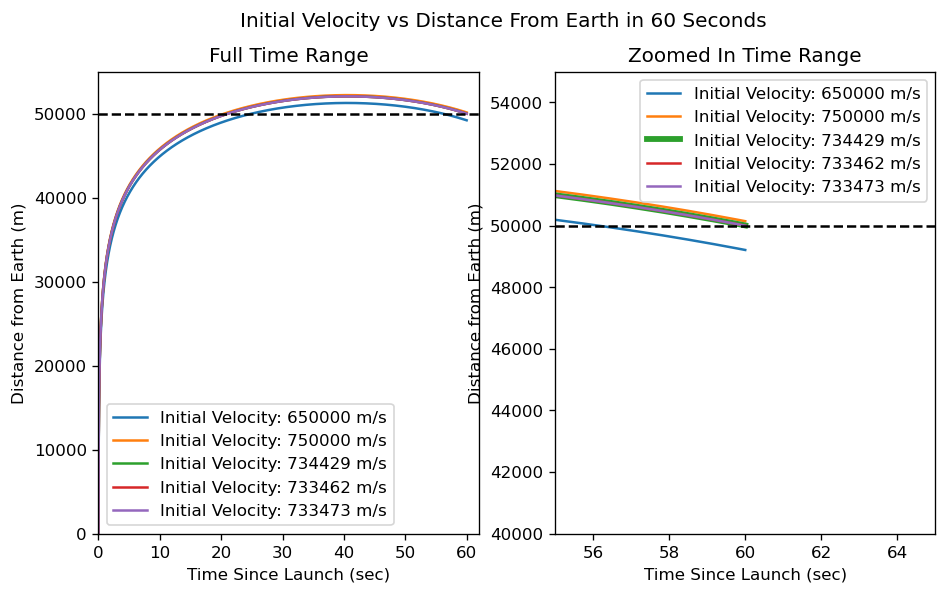

In [60]:
def runge_kutta_4th_shoot_updated(initial_vel, t, step,accel=-9.8):
    old_pos = 0
    old_vel=initial_vel
    t_start, t_end = t[0],t[1]

    t_current = t_start
    
    y_vals = [old_pos]
    
    def acceleration(v):
        return -9.8 - ((5 * 1.225 * 0.005) / (2 * 100)) * (v**2)
    
    while t_current < t_end-step/2:

        k1_vel = acceleration(old_vel)
        k1 = old_vel

        k2 = old_vel+0.5*k1_vel*step
        k2_vel = acceleration(old_vel + 0.5*k1_vel*step) #+0.5*k1_vel*step

        k3=old_vel + 0.5*k2_vel*step
        k3_vel = acceleration(old_vel +0.5*k2_vel*step)

        k4 = old_vel + k3_vel*step
        k4_vel = acceleration(old_vel +k3_vel*step)

        current_vel = old_vel + (1/6)*(k1_vel+ 2*k2_vel + 2*k3_vel+k4_vel)*step

        current_pos = old_pos + (1/6) * (k1 + 2*k2 + 2*k3 + k4) * step

        old_vel = current_vel
        old_pos = current_pos

        y_vals.append(current_pos)
        t_current += step

    return y_vals, y_vals[-1]

shooter_results2 = shooter(50000, 650000.0, 750000.0, runge_kutta_4th_shoot_updated, \
[0,60], 0.001, 0.001)
print(f"Shooter Method Initial Velocity Guesses: {shooter_results2[1]} m/s")

print(f"Our required initial velocity by the SHOOTER METHOD is \
{shooter_results2[1][4]} m/s.")


plt.figure(figsize=(9, 5), dpi=120)
time_range = np.linspace(0,60,len(shooter_results2[2][0][0]))

plt.suptitle("Initial Velocity vs Distance From Earth in 60 Seconds")

plt.subplot(121)
plt.title("Full Time Range")
plt.plot(time_range, shooter_results2[2][0][0],\
         label = f"Initial Velocity: {shooter_results2[1][0]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][1][0],\
         label = f"Initial Velocity: {shooter_results2[1][1]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][2][0],\
         label = f"Initial Velocity: {shooter_results2[1][2]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][3][0],\
         label = f"Initial Velocity: {shooter_results2[1][3]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][4][0],\
         label = f"Initial Velocity: {shooter_results2[1][4]:.6g} m/s")
plt.ylim(0,55000)
plt.xlim(0,62)
plt.xlabel("Time Since Launch (sec)")
plt.ylabel("Distance from Earth (m)")
plt.axhline(y=50000,linestyle="--", c="black")
plt.legend()


plt.subplot(122)
plt.title("Zoomed In Time Range")
plt.plot(time_range, shooter_results2[2][0][0],\
         label = f"Initial Velocity: {shooter_results2[1][0]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][1][0],\
         label = f"Initial Velocity: {shooter_results2[1][1]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][2][0],\
         label = f"Initial Velocity: {shooter_results2[1][2]:.6g} m/s",\
            linestyle="-",linewidth=3.5)
plt.plot(time_range, shooter_results2[2][3][0],\
         label = f"Initial Velocity: {shooter_results2[1][3]:.6g} m/s")
plt.plot(time_range, shooter_results2[2][4][0],\
         label = f"Initial Velocity: {shooter_results2[1][4]:.6g} m/s")
plt.ylim(40000,55000)
plt.xlim(55,65)
plt.xlabel("Time Since Launch (sec)")
plt.ylabel("Distance from Earth (m)")
plt.axhline(y=50000,linestyle="--", c="black")
plt.legend()
plt.show()



(f) Solve using the `scipy.integrate.solve_bvp` method. How does this result compare to your solution from part (e)?

Our required initial velocity by SOLVE_BVP is 733461.9979029758 m/s.


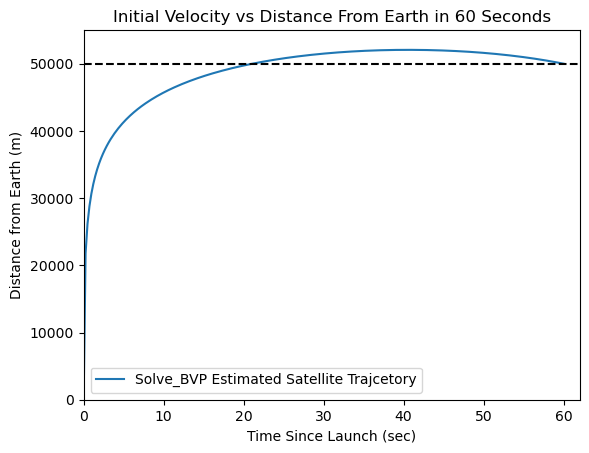

In [22]:
from scipy.integrate import solve_bvp

#this is our ODE. it consists of our 2 first order linear equations
#we use np.vstack, as we want two rows, one column. 
#the first row represents our velocity
#the second row represents our acceleration
#in this case, y[0] is position, y[1] is velocity. 
#from our initial equations, velocity is v[1], so velocity = velocity
#and our acceleration uses our velocity, which is why v[1] is included

def fun(x,y):
    return np.vstack( (y[1],(-9.8 - ((5 * 1.225 * 0.005) / (2 * 100)) * (y[1]**2))))

#these are our boundary conditions
#ya is the front, yb is the end
#ya[0] is position at front, yb[1] is velocity at the end
#our initial conditions is position =0 at start, and position = 50,000 at end.
#similar to the CFD method, we set our "end position" = our current end position - BC2, 
# and solve for that. ideally, it should be zero. 

def bc(ya,yb):
    return np.array([ ya[0],yb[0]-50000])

#the time range
x=np.linspace(0,60,100)

#finally, our y values. this conssists of two rows for position and velocity
#this is what we're trying to solve for, specically y[0]
y=np.zeros((2,x.size))

#however, we cant have velocity constant at 0, or else the function will "die"
#we set it to be an arbitrary value. 
#NOTE: this is not an INITIAL velocity, it's an overall velocity.
#  we shouldn't set it to be 733000
y[1] = 10

curve = solve_bvp(fun,bc,x,y)
x_plot = np.linspace(0,60,250)

#curve.sol is a function (of our x values)
#it provides us a function of x vals of [0] position and [1] velocity
#we only want position, so we do [0]
y_plot = curve.sol(x_plot)[0]

#indexexes into our velocities given our INITIAL TIME RANGE INPUTTED INTO FUNCTION
velocities = curve.yp
print(f"Our required initial velocity by SOLVE_BVP is {velocities[0][0]} m/s.")

plt.plot(x_plot,y_plot,label = "Solve_BVP Estimated Satellite Trajcetory")
plt.ylim(0,55000)
plt.xlim(0,62)
plt.xlabel("Time Since Launch (sec)")
plt.ylabel("Distance from Earth (m)")
plt.axhline(y=50000,linestyle="--", c="black")
plt.title("Initial Velocity vs Distance From Earth in 60 Seconds")

plt.legend()
plt.show()

We can see that the SOLVE_BVP function also converges, and comparing it to other answer from part e, the answers are very similar. If we use the metric of estimated intiial velocity, our velocity was 733472.67 m/s, and the SOLVE_BVP's velocity was 733461.99, which is very similar to each other. This value could probably be varied based on using chanigng the tol or bc_tol arguments in the function. 

Explore the $g$ and $C_d$ parameter space.  Under what conditions does the force of gravity dictate the arc of the satellite?  Under what conditions does the drag force dominate?

We can see that the acceleration formula is comprised of two main parts. The first is downwards gravitational acceleration (-9.8) that is slowing down the satellite, and the second is drag $\frac{\rho A C_d}{2m} \left(\frac{dy}{dt}\right)^2$. 

To answer this question, we want to see under what conditions does the first part (gravity) or second part (drag) of acceleration dominates (contributes more).

Gravity dictates more when this $\frac{\rho A C_d}{2m} \left(\frac{dy}{dt}\right)^2$ term is small. This is affected by the surface area, density, and mass of the satellite, and if these values decrease, decrease, and increase, respectively, the drag will go down and gravity will dominate. However, I think that the key thing is Cd, which is the drag coefficient. This is probably the dominating factor in determining how efficiently the satellite flies through the air. Looking at values online, a drag coefficient of a flat square is Cd = 1.28, which is massive. This would mean that the Cd value would be 256 times more contributing than our current Cd value, causing the drag force to dominate signifigantly. Values smaller than 0.005 would cause the gravity part to dominate (however, in real life there are probably very few things with a drag coefficent smaller than 0.005). 

In summary, the drag force dominates primarily when the drag coefficient is large, the satellite is dense, has a small surface area, and a small mass. Also when the velocity is very large(as it includes a velocity term). Gravitational force dominates when there's a large mass (PE = mass * g *h, larger mass = more force), smaller density, surface area, drag coefficient, and less velocity. 

In [ ]:
from scipy.integrate import solve_bvp

def fun(x,y):
    return np.vstack( (y[1],(-9.8 - ((5 * 1.225 * 0.005) / (2 * 100)) * (y[1]**2))))

def bc(ya,yb):
    return np.array([ ya[0],yb[0]-50000])

x=np.linspace(0,60,100)

y=np.zeros((2,x.size))

y[1] = 10

curve = solve_bvp(fun,bc,x,y)
x_plot = np.linspace(0,60,250)

#curve.sol is a function (of our x values)
#it provides us a function of x vals of [0] position and [1] velocity
#we only want position, so we do [0]
y_plot = curve.sol(x_plot)[0]

#indexexes into our velocities given our INITIAL TIME RANGE INPUTTED INTO FUNCTION
velocities = curve.yp
print(f"Our required initial velocity by SOLVE_BVP is {velocities[0][0]} m/s.")

plt.plot(x_plot,y_plot,label = "Solve_BVP Estimated Satellite Trajcetory")
plt.ylim(0,55000)
plt.xlim(0,62)
plt.xlabel("Time Since Launch (sec)")
plt.ylabel("Distance from Earth (m)")
plt.axhline(y=50000,linestyle="--", c="black")
plt.title("Initial Velocity vs Distance From Earth in 60 Seconds")

plt.legend()
plt.show()